In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# uncomment if you want to see file paths
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input is where you will find the data
/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/test/fake/[].[]

In [2]:
# required libraires
import tensorflow.keras as keras
import math
import time
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import cv2 # image reading
import random # randomizing data
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

below are some attempts at accessing the images to make them valid input for the CNN
somethings to consider, greyscale them for now, then handle the many colors later.
another note, for the CNN, images need to be same size, so I need to resize them.

In [3]:
image1 = cv2.imread("/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/test/fake/0001.jpg",cv2.IMREAD_GRAYSCALE)

In [4]:
image1.shape

(853, 853)

<Axes: >

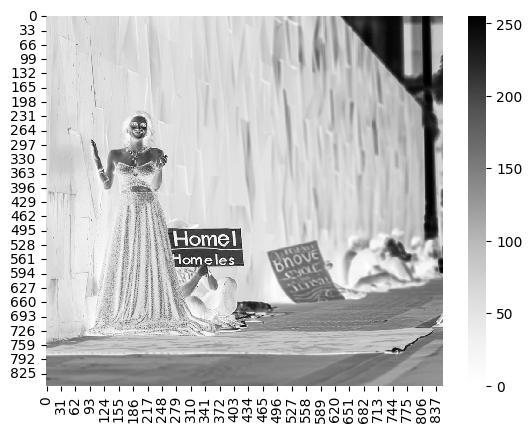

In [5]:
sns.heatmap(image1, cmap=plt.cm.Greys)

In [6]:
# values are already small, may consider not dividing by 255, the division by 255 is for the CNN to deal with small values
# nvm, /by 255 is needed, for some reason it changed, now be fore division values are pretty huge, its cause you ran it many times
print(f"before {image1}")
image1 = image1 / 255.0
print(f"after {image1}")

before [[ 59  59  60 ... 180 178 176]
 [ 59  60  61 ... 179 176 174]
 [ 61  61  62 ... 176 173 171]
 ...
 [149 149 149 ... 131 131 130]
 [147 147 147 ... 131 131 130]
 [146 146 146 ... 131 131 130]]
after [[0.23137255 0.23137255 0.23529412 ... 0.70588235 0.69803922 0.69019608]
 [0.23137255 0.23529412 0.23921569 ... 0.70196078 0.69019608 0.68235294]
 [0.23921569 0.23921569 0.24313725 ... 0.69019608 0.67843137 0.67058824]
 ...
 [0.58431373 0.58431373 0.58431373 ... 0.51372549 0.51372549 0.50980392]
 [0.57647059 0.57647059 0.57647059 ... 0.51372549 0.51372549 0.50980392]
 [0.57254902 0.57254902 0.57254902 ... 0.51372549 0.51372549 0.50980392]]


<Axes: >

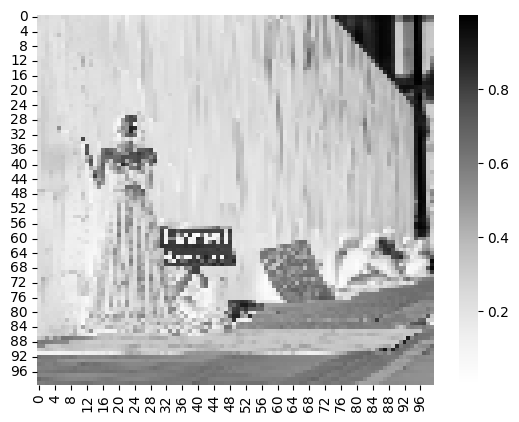

In [7]:
image2 = cv2.imread("/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/test/fake/0002.jpg",cv2.IMREAD_GRAYSCALE)
# print(image2.shape)
# shape was different, so need to resize for uniformity

image1 = cv2.resize(image1, (100,100))
image2 = cv2.resize(image2, (100,100))
train = [image1, image2]

X_train = np.array(train)

X_train.shape

sns.heatmap(X_train[0], cmap=plt.cm.Greys)

Due to the size of the dataset I'm dealing with (about 52GB), Kaggle is essentially bugging out and not processing it all in reasonable time. So instead, I'm going to go through the data bit by bit to not crash Kaggle. This is inefficient but it works.

initializing lists

In [8]:
train = []
train_key = []
test = []
test_key = []



X_train = np.array([])
y_train = np.array([])

X_test = np.array([])
y_test = np.array([])


creating function for traversing through data

In [9]:
def traverse(path, storage, keys, num, r_or_f):
    count = 0
    for filename in os.listdir(path):
        fpath = str(os.path.join(path, filename))
        image = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
    
        if image is not None:
            image = cv2.resize(image, (100,100))
            image = image / 255.0
    
            storage.append(image)
            keys.append(r_or_f)
    
            count += 1
            if count == num:
                break

In [10]:
train_r_path = "/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/train/real"

traverse(train_r_path, train, train_key, 5000, 1)

Corrupt JPEG data: 417 extraneous bytes before marker 0xd9
Premature end of JPEG file


In [11]:
train_f_path = "/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/train/fake"

traverse(train_f_path, train, train_key, 5000, 0)

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 620 extraneous bytes before marker 0xd9
Corrupt JPEG data: 66374 extraneous bytes before marker 0xd9
Corrupt JPEG data: 4944 extraneous bytes before marker 0xd9
Corrupt JPEG data: 6274 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 25160 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 102466 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 7795 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment


In [12]:
test_r_path = "/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/test/real"

traverse(test_r_path, test, test_key, 3000, 1)

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 9 extraneous bytes before marker 0xda


In [13]:
test_f_path = "/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images/test/fake"

traverse(test_f_path, test, test_key, 3000, 0)

Corrupt JPEG data: 26122 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 28373 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2811 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 4792 extraneous bytes before marker 0xd9
Corrupt JPEG data: 12129 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 107 extraneous bytes before marker 0xd9
Corrupt JPEG data: 234594 extraneous bytes before marker 0xd9
Corrupt JPEG data: 24 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment


In [14]:
print(f"training length: {len(train)} testing length: {len(test)}")

training length: 10000 testing length: 6000


In [15]:
# print(train_key)
# print(test_key)

tr = list(zip(train, train_key))
te = list(zip(test, test_key))

random.shuffle(tr)
random.shuffle(te)

train, train_key = zip(*tr)
test, test_key = zip(*te)

# print(train_key)
# print(test_key)


to free up memory, del [] to free up memory cause I can't have repeated lists, way to much memory

In [16]:
X_train = np.array(train)
del train

y_train = np.array(train_key)
del train_key

X_test = np.array(test)
del test

y_test = np.array(test_key)
del test_key

print(f"train shape: {X_train.shape} train_key shape: {y_train.shape}")
print(f"test shape: {X_test.shape} test_key shape: {y_test.shape}")

train shape: (10000, 100, 100) train_key shape: (10000,)
test shape: (6000, 100, 100) test_key shape: (6000,)


CNN requires 4-D input vector (num examples, image_dimension_X, image_dimension_Y, num_channels

In [17]:
X_train = np.reshape(X_train, (X_train.shape[0], 100, 100, 1))
X_test = np.reshape(X_test, (X_test.shape[0], 100, 100, 1))

num_ex = X_train.shape[0]